## 1. Khởi tạo Môi trường Deep Learning 
Thiết lập không gian làm việc chuyên biệt cho nhánh Học sâu (Deep Learning). Khai báo các thư viện Keras/TensorFlow phục vụ cho việc xây dựng đồ thị tính toán của kiến trúc LSTM-Autoencoder.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Khai báo hệ sinh thái Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import roc_auc_score, f1_score, roc_curve

sns.set_theme(style="whitegrid")

# Cố định random seed để đảm bảo khả năng tái lập (Reproducibility)
tf.random.set_seed(42)
np.random.seed(42)

print(f"[INFO] Phiên bản TensorFlow đang sử dụng: {tf.__version__}")

[INFO] Phiên bản TensorFlow đang sử dụng: 2.21.0


## 2. Trích xuất Dữ liệu & Biến đổi Không gian Tensor 3D
Thuật toán LSTM yêu cầu cấu trúc dữ liệu đầu vào có tính tuần tự. Triển khai kỹ thuật Cửa sổ trượt để tái cấu trúc ma trận đặc trưng 2D thành Tensor 3D với chiều $(Samples, Timesteps, Features)$. 
Quy mô của $Timesteps$ sẽ quyết định "độ dài bộ nhớ" mà mô hình dùng để tái tạo lại tín hiệu.

In [2]:
# --- Tự động dò đường dẫn ---
current_dir = os.getcwd()
PROJECT_ROOT = os.path.dirname(current_dir) if os.path.basename(current_dir) == 'notebooks' else current_dir

df_train = pd.read_csv(os.path.join(PROJECT_ROOT, "data", "features", "T1_train.csv"))
df_test = pd.read_csv(os.path.join(PROJECT_ROOT, "data", "features", "T1_test.csv"))

# Lọc không gian đặc trưng cốt lõi (z-score, diff)
features = [col for col in df_train.columns if ('zscore' in col) or ('diff' in col)]
X_train_raw = df_train[features].values
X_test_raw = df_test[features].values

# Lấy lại hệ quy chiếu nhãn giả từ phần dư công suất (Power Residual)
mean_val, std_val = df_train['power_residual'].mean(), df_train['power_residual'].std()
y_test_pseudo_raw = ((df_test['power_residual'] < (mean_val - 3 * std_val)) | 
                     (df_test['power_residual'] > (mean_val + 3 * std_val))).astype(int).values

# --- Kỹ thuật Sliding Window ---
def create_sequences(X, y=None, time_steps=10):
    """
    Biến đổi ma trận 2D thành Tensor 3D dọc theo trục thời gian.
    """
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        if y is not None:
            # Gắn nhãn cho chuỗi bằng nhãn của điểm cuối cùng trong cửa sổ
            ys.append(y[i + time_steps])
    
    if y is not None:
        return np.array(Xs), np.array(ys)
    return np.array(Xs)

# Cấu hình kích thước cửa sổ
TIME_STEPS = 10

X_train_3d = create_sequences(X_train_raw, time_steps=TIME_STEPS)
X_test_3d, y_test_pseudo = create_sequences(X_test_raw, y_test_pseudo_raw, time_steps=TIME_STEPS)

print(f"[INFO] Kích thước Tensor Train (X_train_3d): {X_train_3d.shape} -> (Samples, Timesteps, Features)")
print(f"[INFO] Kích thước Tensor Test (X_test_3d): {X_test_3d.shape}")
print(f"[INFO] Đồng bộ kích thước Nhãn Test (y_test_pseudo): {y_test_pseudo.shape}")

[INFO] Kích thước Tensor Train (X_train_3d): (36782, 10, 6) -> (Samples, Timesteps, Features)
[INFO] Kích thước Tensor Test (X_test_3d): (15758, 10, 6)
[INFO] Đồng bộ kích thước Nhãn Test (y_test_pseudo): (15758,)


## 3. Khởi tạo Kiến trúc LSTM-Autoencoder
Xây dựng mô hình với cơ chế nút thắt cổ chai để ép mạng nơ-ron phải học cách biểu diễn các đặc trưng cốt lõi của tín hiệu tuabin gió. Mạng sử dụng hàm kích hoạt ReLU và tối ưu hóa bằng Adam.

In [ ]:
def build_lstm_autoencoder(timesteps, num_features):
    """
    Khởi tạo mạng đồ thị tính toán cho LSTM-Autoencoder.
    """
    model = Sequential(name="Wind_Turbine_LSTM_Autoencoder")
    model.add(Input(shape=(timesteps, num_features)))
    # ---------------- ENCODER ----------------
    # Lớp mã hóa 1: Đọc chuỗi thời gian đầu vào
    model.add(LSTM(32, activation='relu', input_shape=(timesteps, num_features), return_sequences=True, name="Encoder_LSTM_1"))
    
    # Lớp mã hóa 2 (Bottleneck): Nén dữ liệu thành vector đặc trưng tiềm ẩn
    model.add(LSTM(16, activation='relu', return_sequences=False, name="Bottleneck_Layer"))
    
    # ---------------- DECODER ----------------
    # Lặp lại vector tiềm ẩn cho đủ số timesteps để chuẩn bị giải mã
    model.add(RepeatVector(timesteps, name="Repeat_Vector"))
    
    # Lớp giải mã 1
    model.add(LSTM(16, activation='relu', return_sequences=True, name="Decoder_LSTM_1"))
    
    # Lớp giải mã 2
    model.add(LSTM(32, activation='relu', return_sequences=True, name="Decoder_LSTM_2"))
    
    # Lớp tái tạo (Reconstruction Layer)
    model.add(TimeDistributed(Dense(num_features), name="Reconstruction_Output"))
    
    # ---------------- COMPILATION ----------------
    model.compile(optimizer='adam', loss='mse')
    
    return model

# Khởi tạo mô hình
timesteps = X_train_3d.shape[1]
num_features = X_train_3d.shape[2]

lstm_ae = build_lstm_autoencoder(timesteps, num_features)
lstm_ae.summary()

c:\Users\Admin\OneDrive\Documents\HOC_BAI\AWS\T1_AD\.venv312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "Wind_Turbine_LSTM_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Encoder_LSTM_1 (LSTM)           │ (None, 10, 32)         │         4,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Bottleneck_Layer (LSTM)         │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Repeat_Vector (RepeatVector)    │ (None, 10, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_LSTM_1 (LSTM)           │ (None, 10, 16)         │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_LSTM_2 (LSTM)           │ (None, 10, 32)         │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Reconstruction_Output           │ (None, 10, 6)          │           198 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,710 (65.27 KB)

 Trainable params: 16,710 (65.27 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Huấn luyện Mô hình LSTM-Autoencoder
Thực thi quá trình huấn luyện trên tập X_train_3d. Sử dụng cơ chế EarlyStopping để tự động dừng huấn luyện khi sai số tập kiểm định (validation loss) không còn cải thiện, giúp tiết kiệm tài nguyên và chống overfitting.

[INFO] Bắt đầu huấn luyện LSTM-Autoencoder...
Epoch 1/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 27s 29ms/step - loss: 0.6918 - val_loss: 0.4625 - learning_rate: 0.0010
Epoch 2/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - loss: 0.5344 - val_loss: 0.4291 - learning_rate: 0.0010
Epoch 3/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - loss: 0.5106 - val_loss: 0.4113 - learning_rate: 0.0010
Epoch 4/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - loss: 0.4888 - val_loss: 0.4052 - learning_rate: 0.0010
Epoch 5/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - loss: 0.4701 - val_loss: 0.3884 - learning_rate: 0.0010
Epoch 6/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - loss: 0.4624 - val_loss: 0.3799 - learning_rate: 0.0010
Epoch 7/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - loss: 0.4395 - val_loss: 0.3656 - learning_rate: 0.0010
Epoch 8/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - loss: 0.4204 - val_loss: 0.3481 - learning_rate: 0.0010
Epoch 9/50
460/460 ━━━━━━━━━━━━━━━━━━━━ 26s 57ms/step - lo

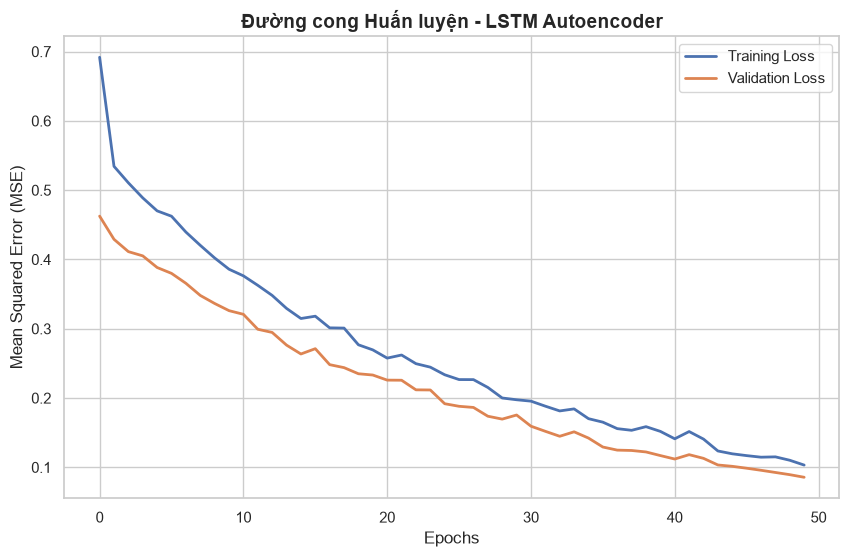

In [4]:
# Khởi tạo các Callbacks kiểm soát huấn luyện
callbacks = [
    EarlyStopping(
        monitor='val_loss', 
        patience=5,          # Dừng nếu sau 5 epochs val_loss không giảm
        restore_best_weights=True, # Trả lại tệp tạ số tốt nhất
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.5,          # Giảm một nửa learning rate nếu mô hình bị chững lại
        patience=2, 
        verbose=1
    )
]

# Siêu tham số huấn luyện
EPOCHS = 50
BATCH_SIZE = 64

print("[INFO] Bắt đầu huấn luyện LSTM-Autoencoder...")
history = lstm_ae.fit(
    X_train_3d, X_train_3d, # Autoencoder: Input và Target giống hệt nhau
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,   # Trích 20% tập train làm tập validation nội bộ
    callbacks=callbacks,
    shuffle=False           # Không shuffle để giữ nguyên tính chuỗi thời gian
)

# Trực quan hóa đường cong học tập (Learning Curve)
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Đường cong Huấn luyện - LSTM Autoencoder', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.legend()
plt.show()

## 5. Đánh giá mức độ dị thường & So sánh ROC-AUC
Sử dụng mô hình LSTM-Autoencoder để dự đoán trên tập kiểm thử (X_test_3d). Trích xuất sai số bình phương trung bình (MSE) cho từng điểm dữ liệu dọc theo trục thời gian và đặc trưng. Tính toán chỉ số ROC-AUC để đối sánh với nhánh Machine Learning.

[INFO] Đang tiến hành dự đoán trên tập Test...
493/493 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step

[KẾT QUẢ CHUNG CUỘC]
-> ROC-AUC của LSTM-Autoencoder: 0.9144


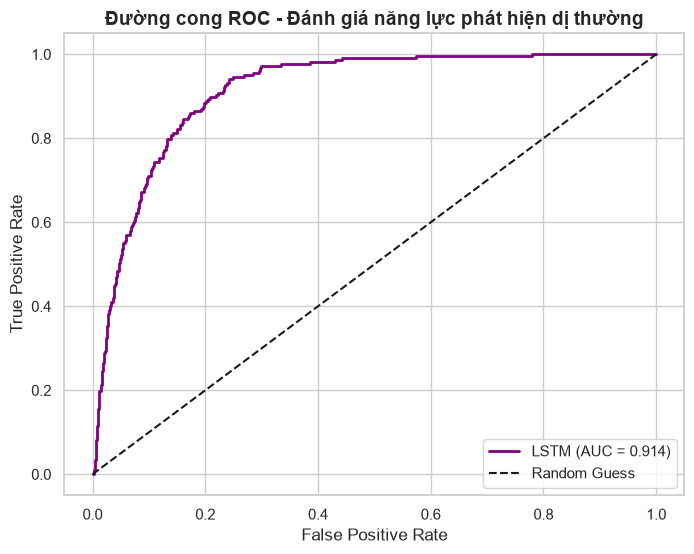

In [5]:
print("[INFO] Đang tiến hành dự đoán trên tập Test...")
# 1. Dự đoán lại tập X_test_3d
X_test_pred = lstm_ae.predict(X_test_3d)

# 2. Tính toán Lỗi tái tạo (MSE) cho TỪNG mẫu dữ liệu
# Trục 1 là Timesteps (10), Trục 2 là Features (6)
mse_test = np.mean(np.square(X_test_3d - X_test_pred), axis=(1, 2))

# 3. Tính toán ROC-AUC
auc_lstm = roc_auc_score(y_test_pseudo, mse_test)
print(f"\n[KẾT QUẢ CHUNG CUỘC]")
print(f"-> ROC-AUC của LSTM-Autoencoder: {auc_lstm:.4f}")

# 4. Trực quan hóa đường cong ROC
fpr_lstm, tpr_lstm, _ = roc_curve(y_test_pseudo, mse_test)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lstm, tpr_lstm, label=f'LSTM (AUC = {auc_lstm:.3f})', color='purple', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.title('Đường cong ROC - Đánh giá năng lực phát hiện dị thường', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc='lower right')
plt.show()